In [ ]:
!pip install gensim nltk matplotlib

In [ ]:
corpus = [
    "Government passes new policy for economic growth",
    "Sports events resume after long break",
    "New technology is transforming global markets",
    "Researchers discover new species in Amazon forest",
    "Stock markets rise as investors gain confidence",
    "Education sector adopts online learning tools",
    "Healthcare workers demand better safety measures",
    "Artificial intelligence improves medical diagnosis",
    "Electric vehicles gain popularity worldwide",
    "Climate change affects wildlife around the globe"]

In [ ]:
corpus

['Government passes new policy for economic growth',
 'Sports events resume after long break',
 'New technology is transforming global markets',
 'Researchers discover new species in Amazon forest',
 'Stock markets rise as investors gain confidence',
 'Education sector adopts online learning tools',
 'Healthcare workers demand better safety measures',
 'Artificial intelligence improves medical diagnosis',
 'Electric vehicles gain popularity worldwide',
 'Climate change affects wildlife around the globe']

# **Text Preprocessing**

In [ ]:
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
punct = set(string.punctuation)

processed_sentence = []

for sent in corpus:
  words = word_tokenize(sent.lower())
  cleaned = [w for w in words if w not in stop_words and w not in punct]
  processed_sentence.append(cleaned)

print("Processed Dataset:")
print(processed_sentence)

Processed Dataset:
[['government', 'passes', 'new', 'policy', 'economic', 'growth'], ['sports', 'events', 'resume', 'long', 'break'], ['new', 'technology', 'transforming', 'global', 'markets'], ['researchers', 'discover', 'new', 'species', 'amazon', 'forest'], ['stock', 'markets', 'rise', 'investors', 'gain', 'confidence'], ['education', 'sector', 'adopts', 'online', 'learning', 'tools'], ['healthcare', 'workers', 'demand', 'better', 'safety', 'measures'], ['artificial', 'intelligence', 'improves', 'medical', 'diagnosis'], ['electric', 'vehicles', 'gain', 'popularity', 'worldwide'], ['climate', 'change', 'affects', 'wildlife', 'around', 'globe']]


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from gensim.models import Word2Vec

# Define and train the Word2Vec skip-gram model
# vector_size: Dimensionality of the word vectors
# window: Maximum distance between the current and predicted word within a sentence
# min_count: Ignores all words with total frequency lower than this
# sg: Training algorithm: 0 for CBOW, 1 for skip-gram
skip_model = Word2Vec(processed_sentence, vector_size=100, window=5, min_count=1, sg=1)

try:
  # Attempt to find the most similar words using the trained model
  result=skip_model.wv.most_similar(positive=["technology","markets"],negative=["education"])
  print("Analogy result:")
  print(result)
except KeyError as e:
  print(f"Analogy not found in small dataSET. Word not in vocabulary: {e}")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Analogy result:
[('wildlife', 0.18598198890686035), ('better', 0.1775805801153183), ('online', 0.15989819169044495), ('economic', 0.13005244731903076), ('vehicles', 0.12310083210468292), ('species', 0.1184229701757431), ('resume', 0.11803654581308365), ('climate', 0.11741740256547928), ('learning', 0.1140461191534996), ('stock', 0.1113102063536644)]


In [ ]:
from gensim.models import Word2Vec

In [ ]:
from sklearn.decomposition import PCA
from matplotlib import pyplot

In [ ]:
words=["technology","education","researchers","government","forest","healthcare"]

In [ ]:
word_vectors=[skip_model.wv[word] for word in words]

In [ ]:
pca_model = PCA(n_components=2)
points=pca_model.fit_transform(word_vectors)

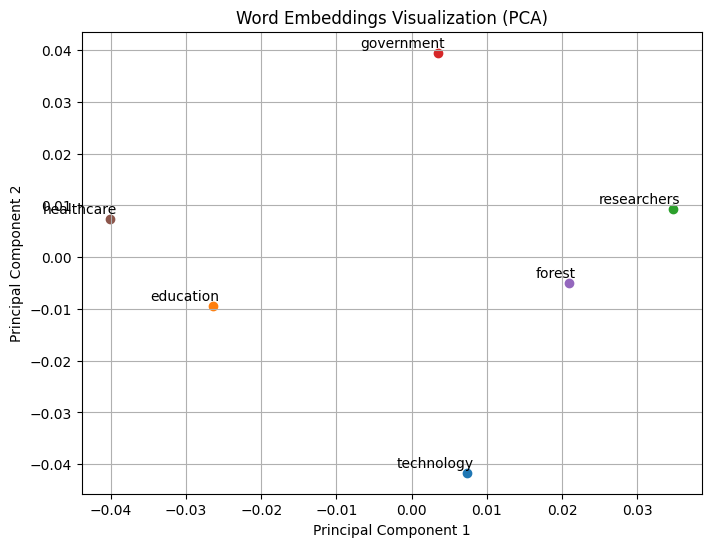

In [ ]:
pyplot.figure(figsize=(8, 6))
for i, word in enumerate(words):
    pyplot.scatter(points[i, 0], points[i, 1])
    pyplot.annotate(word, xy=(points[i, 0], points[i, 1]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
pyplot.xlabel('Principal Component 1')
pyplot.ylabel('Principal Component 2')
pyplot.title('Word Embeddings Visualization (PCA)')
pyplot.grid(True)
pyplot.show()